# SHAP deep explainer

In [19]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


In [20]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import tensorflow as tf

from anomaly.utils import specobjid_to_idx
from astroExplain.spectra.notebook import (
    interpret,
    explain_reconstruction_score,
)
from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data ingestion

In [21]:
def data_ingestion(
    metric,
    bin_id,
    spectra_dir,
    # explanations_dir
):
    """
    Function to load the data for a given metric and bin_id.
    """

    data_dict = {
        "metric": metric,
        "anomalies": None,
        "anomalies_df": None,
    }
    # anomalies
    data_dict["anomalies"] = np.load(
        f"{spectra_dir}/{bin_id}/"
        f"{data_dict['metric']}/top_anomalies.npy",
        mmap_mode="r"
    )

    data_dict["anomalies_df"] = pd.read_csv(
        f"{spectra_dir}/{bin_id}/"
        f"{data_dict['metric']}/top_anomalies.csv.gz",
        index_col="specobjid",
    )

    # normal
    data_dict["normal"] = np.load(
        f"{spectra_dir}/{bin_id}/"
        f"{data_dict['metric']}/top_normal.npy",
        mmap_mode="r"
    )
    data_dict["normal_df"] = pd.read_csv(
        f"{spectra_dir}/{bin_id}/"
        f"{data_dict['metric']}/top_normal.csv.gz",
        index_col="specobjid",
    )

    return data_dict

# Directories

In [22]:
bin_id = "bin_03"
phd_dir = "/home/elom/phd/00_phd_code"
# data
spectra_dir = f"{phd_dir}/spectra"
shap_dir = f"{phd_dir}/explanations/shap"
# model
ae_dir = f"{phd_dir}/models/{bin_id}/vae"

# Data ingestion

In [23]:
# data_dir = "/home/elom/spectra"
# model_dir = "/home/elom/models"
# bin_id = "bin_03"

In [24]:
# all_meta_data_df = pd.read_csv(
#     f"{spectra_dir}/drop_0_01_z_0_5_4_0_snr_inf.csv.gz",
#     index_col="specobjid",
# )
# all_meta_data_df.shape

In [25]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
# convert wave from Angstroms to nanometers
wave = wave / 10.0
spectra_bin_03 = np.load(
    f"{spectra_dir}/{bin_id}/{bin_id}_fluxes.npy",
    mmap_mode="r"
)

all_spectra =  np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

n_bin_spectra = spectra_bin_03.shape[0]
n_top_1_percent = int(n_bin_spectra * 0.01)
print(f"Number of spectra: {n_bin_spectra}")
print(f"Top 1% spectra: {n_top_1_percent}")

idx_specobjid_map = np.load(
    f"{spectra_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
)
# print shap

Number of spectra: 181850
Top 1% spectra: 1818


## Load model

In [26]:
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{ae_dir}",
)

# MSE

In [27]:
mse_metric_str = "mse_noRel100"
mse_data_dict = data_ingestion(
    metric=mse_metric_str,
    bin_id=bin_id,
    spectra_dir=spectra_dir,
    # explanations_dir=explanations_dir,
)
mse_data_dict.keys()

dict_keys(['metric', 'anomalies', 'anomalies_df', 'normal', 'normal_df'])

## Score model

In [28]:
ae_model.model.input, ae_model.model.output['reconstruction']

(<KerasTensor shape=(None, 3773), dtype=float32, sparse=False, ragged=False, name=encoder_input>,
 <KerasTensor shape=(None, 3773), dtype=float32, sparse=False, ragged=False, name=keras_tensor_107>)

In [29]:
from astroExplain.shap import scoreModels as shapModels
# from keras import ops

in_tensor = ae_model.model.input
out_tensor = ae_model.model.output['reconstruction']

score_model = shapModels.build_mse_score_model(
    in_tensor=in_tensor,
    out_tensor=out_tensor,
    print_summary=False
)
# # squared_error = ops.square(in_tensor - out_tensor)
# # score = ops.mean(squared_error, axis=-1)
# # print(f"Shape of the score tensor: {score.shape}")
# # score = ops.expand_dims(score, axis=-1)
# # print(f"Shape of the score tensor after expansion: {score.shape}")
# # # Define the new Keras model
# # score_model = tf.keras.Model(inputs=in_tensor, outputs=score)

Shape of the score tensor: (None,)
Shape of the score tensor after expansion: (None, 1)


In [32]:
bg_spectra = mse_data_dict["normal"][:1000]

mse_explainer = shap.DeepExplainer(score_model, bg_spectra)

bad_data = {
    'specobjid': 637325355518027776,
    'metric': 'mse_noRel100',
    'explanation': 'uniform_64_scale_0.9',
}

specobjid = bad_data["specobjid"]

idx_spectrum = specobjid_to_idx(specobjid, idx_specobjid_map)
spectrum = all_spectra[idx_spectrum].reshape(1, -1)
print(f"Shape of the spectrum: {spectrum.shape}")

start_time = time.perf_counter()
explanation = mse_explainer.shap_values(spectrum, ranked_outputs=1)
finish_time = time.perf_counter()
dt = finish_time - start_time
print(f"Time taken to compute SHAP values: {dt:.2f} seconds")

Shape of the spectrum: (1, 3773)
Time taken to compute SHAP values: 0.21 seconds


Text(0, 0.5, 'SHAP value')

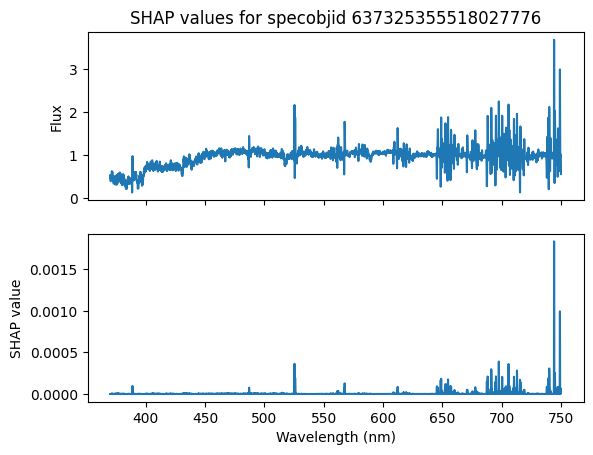

In [33]:
# plot shap values
fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].plot(wave, spectrum[0])
axs[0].set_ylabel("Flux")
axs[0].set_title(f"SHAP values for specobjid {specobjid}")
axs[1].plot(wave, explanation[0][0])
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_ylabel("SHAP value")

## Explainer

## bad data reduction